# Tutorial 11 - add_efficiency_coulomb

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_dataframes = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [4]:
standardized_data = eet.merge_into_series(standardized_dataframes)

In [5]:
df_primitives = eet.add_primitive_segments(standardized_data, config=eet.PrimitiveConfig.DEFAULT)

In [6]:
df_segments = eet.extract_sequence_overview(df_primitives, config=eet.SequenceOverviewConfig.STEP_ANALYZER)

In [7]:
eet.BatteryConfig.DEFAULT

_BatteryConfigClass(cell_name='Default', c_ref=4.8, soc_start=0, max_voltage=4.2, min_voltage=2.5, threshold_current=0.075, voltage_intervall=0.01, minimal_current_for_capacity=-1.2, maximal_current_for_capacity=-0.8, min_current_diff=0.5, max_time_diff=0.5, min_voltage_diff=0, ignore_negative_resistance_values=False)

## Step 1: Filter blocks

In [8]:
charge_blocks, _ = eet.filter_and_split_df_by_blocks(
    df_segments_and_sequences=df_segments, df_primitives=df_primitives, rules=["CC_Charge"]
)

discharge_blocks, _ = eet.filter_and_split_df_by_blocks(
    df_segments_and_sequences=df_segments, df_primitives=df_primitives, rules=["CCCV_Discharge"]
)
charge_blocks

[       Test_Time[s]  Voltage[V]  Current[A]  Power[W]  ID Meta_Data  \
 29972       29971.8      2.5996      1.4398  3.742904   5      None   
 29973       29972.8      2.6144      1.4400  3.764736   5      None   
 29974       29973.8      2.6251      1.4400  3.780144   5      None   
 29975       29974.8      2.6340      1.4401  3.793223   5      None   
 29976       29975.8      2.6421      1.4401  3.804888   5      None   
 ...             ...         ...         ...       ...  ..       ...   
 41245       41244.8      4.2000      1.4391  6.044220   5      None   
 41246       41245.8      4.2000      1.4391  6.044220   5      None   
 41247       41246.8      4.2001      1.4391  6.044364   5      None   
 41248       41247.8      4.2002      1.4389  6.043668   5      None   
 41249       41248.8      4.2002      1.4377  6.038628   5      None   
 
        Step_Count  Temperature[°C]           Date_Time EIS_f[Hz]  ...  \
 29972         4.0             25.2 2024-02-01 18:28:35     

discharge_blocks## Step 2: add_efficiency_coulomb

<Axes: xlabel='Test_Time[s]'>

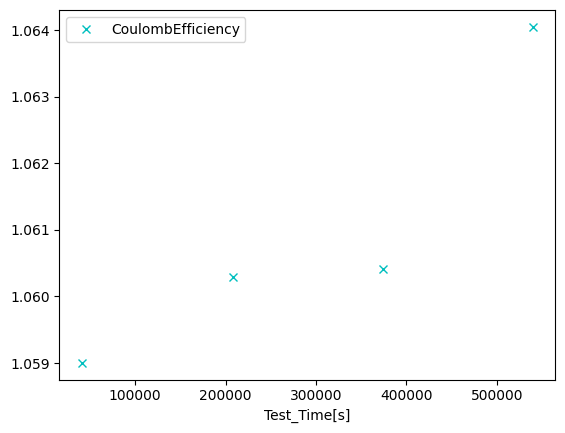

In [9]:
eet.add_efficiency_coulomb(
    df=standardized_data,
    df_blocks_charge=charge_blocks,
    df_blocks_discharge=discharge_blocks,
    config=eet.BatteryConfig.DEFAULT,
    verbose=True,
    ignore_threshold_values=True,  # TODO
).plot(x="Test_Time[s]", y="CoulombEfficiency", style="cx")